03_modelling.ipynb
------------------
This notebook experiments with different ML models to find the best one
for predicting which NHS hospitals will experience high pressure months 
(breach rate > 30%).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [26]:
df = pd.read_csv("../data/processed/nhs_processed.csv")
df.shape

(4433, 26)

# Now sorting the data by time before splitting

In [27]:
df = df.sort_values("period")

df["period"].head(5)

0    MSitAE-APRIL-2022
1    MSitAE-APRIL-2022
2    MSitAE-APRIL-2022
3    MSitAE-APRIL-2022
4    MSitAE-APRIL-2022
Name: period, dtype: str

- Now setting up TimeSeriesSplit and train the first model , Logistic Regression baseline.

In [28]:
# Defining X and y before splitting

# features from which the model predicts
X = df[["type1_att", "admission_rate", "severe_wait_ratio"]]

# target variable
y = df["breached"]

- cross validation. Testing multiple times to get a trustworthy score.

In [29]:
tscv = TimeSeriesSplit(
    n_splits=5
)  # time series cross validator - It doesn't contain the actual data. It contains the instructions for how to split.
print(tscv)
print(type(tscv))

# tscv is  a configuration object - it stores the settings for how to split.

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
<class 'sklearn.model_selection._split.TimeSeriesSplit'>


- What it contains is a TimeSeriesSplit object - like a machine that knows how to generate those 5 splits.

- then tscv.split(X) will be used to run the machine on my data X and give me the row numbers for each split

# Logistic Regression 

Logistic Regression needs scaling because it learns weights using gradient descent and numerical optimization. Without scaling, features with very large values can dominate the learning process and make optimization unstable.

- target leakage: The model accidentally gets information during training that would not be available in real-world prediction time.

In [30]:
lr_scores = []  # a list for storing all 5 f1_score from timesplitseries

# train_idx and test_idx is the row numbers of input features X
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # What StandardScaler does : It rescales every feature to the same range — mean of 0, standard deviation of 1.

    scaler = StandardScaler()  # creates the scaler object/tool.
    # scaler: empty StandardScaler object. Like buying a weighing scale before using it. It exists but hasn't measured anything yet.
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # model training
    logistic_model = LogisticRegression(class_weight="balanced", random_state=42)
    logistic_model.fit(X_train_scaled, y_train)

    # model prediciting
    y_pred = logistic_model.predict(X_test_scaled)

    # classification_report : gives the accuracy,precision,recall , f1_score
    report = classification_report(y_test, y_pred, output_dict=True)
    lr_scores.append(report['1']['f1-score'])     # appending 1 "breached class" then "f1_score" value 

print(f'Logistic Regression Average F1: {np.mean(lr_scores):.3f}')



Logistic Regression Average F1: 0.748


    # What fit_transform() means
    # fit Learns:

    # mean and standard deviation from the data.

    # transform means: 

    # Uses those values to scale the data.

- Baseline: Logistic Regression F1 = 0.748

Note: Initial score was 0.989 due to target leakage, breach_rate was 
included as a feature but was directly used to create the target variable 
breached. Removed breach_rate from features. Real score is 0.748.
This is our baseline now every subsequent model must beat this.

# Random Forest :

Random Forest is an ensemble learning algorithm made of multiple decision trees. Each tree learns different rule-based patterns from random subsets of the data and features, and the final prediction is made through majority voting or averaging. It is powerful because combining many diverse trees improves generalization and reduces overfitting.

In [31]:
# now training on random forest 

rf_scores = []  ## a list for storing all 5 f1_score from timesplitseries

for train_idx , test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # no scaling needed for random forest 
    # model_training 
    random_forest = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)  
    # n_estimators=100 = build 100 decision trees.
    
    random_forest.fit(X_train,y_train)

    y_pred = random_forest.predict(X_test)

    report = classification_report(y_test,y_pred,output_dict=True)
    rf_scores.append(report['1']['f1-score'])

print(f'Random Forest Average F1: {np.mean(rf_scores):.3f}')

Random Forest Average F1: 0.939


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.51      0.59        89
           1       0.93      0.97      0.95       649

    accuracy                           0.91       738
   macro avg       0.82      0.74      0.77       738
weighted avg       0.91      0.91      0.91       738



- Random Forest F1: 0.939 (vs Logistic Regression baseline: 0.748)

- Strong recall on breached class (0.97): model catches almost all crises.
- Weak recall on not-breached class (0.51): model struggles to identify 
healthy hospitals, too many false alarms.

- Root cause: class imbalance. 649 breached vs 89 not breached in test split.
- Next step: visualise feature importance to understand what drives predictions.

# feature_importance

- Feature importance tells which features the Random Forest relied on most to make predictions.

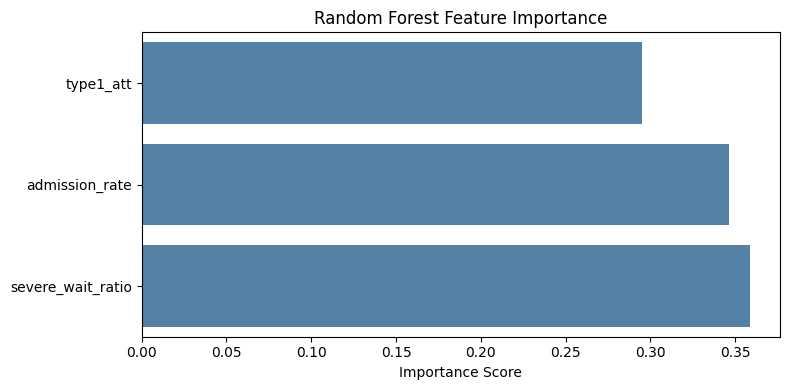

In [34]:
features_names = ['type1_att', 'admission_rate', 'severe_wait_ratio']
importances = random_forest.feature_importances_

# plotting graph
plt.figure(figsize=(8,4))
sns.barplot(x=importances, y=features_names, color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/06_feature_importance.png')
plt.show()

- All three features contribute roughly equally to predictions (30-35% each).
- Admission rate and severe wait ratio capture systemic hospital pressure.
- Type 1 attendance contributes despite weak direct correlation - Random Forest 
- uses it in combination with other features, not in isolation.

# Confusion Matrix
- A confusion matrix is a table used to evaluate classification models by comparing actual labels with predicted labels, showing true positives, true negatives, false positives, and false negatives.

---------------  Predicted
- ----------- -------  Yes   ***
    No

- Actual Yes -----    TP    ***    FN

- Actual No  ------   FP    ***    TN

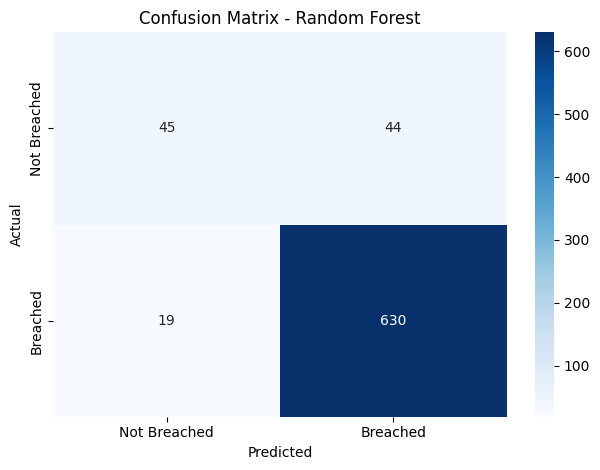

In [ ]:
# confusion matrix
confuse_matrix = confusion_matrix(y_test, y_pred)   # compares the actual answers with the model's predictions and produces a 2x2 table.

sns.heatmap(confuse_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Breached', 'Breached'],
            yticklabels=['Not Breached', 'Breached'])

# - confuse_matrix: the 2x2 table of numbers we just created. This is the data.
# - annot=True: write the actual numbers inside each box. Without this you just see colours with no numbers.
# - fmt='d': format the numbers as integers. Without this you might see 45.0000 instead of 45.
# - cmap='Blues': colour scheme. Higher numbers = darker blue. Lower numbers = lighter blue.
# - xticklabels: labels for the columns (what the model predicted).
# - yticklabels: labels for the rows (what actually happened).

plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/figures/07_confusion_matrix.png')
plt.show()

- 630 breached hospitals correctly identified (97% recall).
- Only 19 missed , acceptable for patient safety context.
- 44 healthy hospitals wrongly flagged , model is too aggressive 
- on the minority class. Acceptable tradeoff given our priority 
- is catching real crises over avoiding false alarms.

# ROC- AUC

- ROC-AUC measures a classification model’s ability to distinguish between classes across all thresholds. It evaluates how well the model ranks positive cases higher than negative cases, with higher scores indicating better class separation.

In [38]:
# AUC score
auc = roc_auc_score(y_test, random_forest.predict_proba(X_test)[:, 1])
print(f'AUC Score: {auc:.3f}')

AUC Score: 0.888
